# Research Question 1: 

The goal: for each ecoregion, estimate how strongly and in which direction pre-season climate anomaly predicts fire season onset timing (β, days/°C), using statsmodels.MixedLM with partial pooling across ecoregions.


In [75]:
# Imports

import pandas as pd
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
import os

print('Libraries loaded.')

pd.set_option('display.expand_frame_repr', False)

Libraries loaded.


In [76]:
# 

RUN_LABEL   = 'med_basin'  # short name for this run
RUN_VERSION = 'v4'         # increment this for each new run
RUN_NAME   = f'{RUN_LABEL}_{RUN_VERSION}'

In [95]:
# Config (paths, grid definitions)

RESPONSE_VARS  = ['onset_doy', 'peak_doy', 'end_doy', 'season_length']
LAG_WINDOWS    = [30, 45, 60, 90]
PREDICTOR_SETS = {
    'temp':      ['temp_anomaly_{lag}d'],
    'precip':    ['precip_anomaly_{lag}d'],
    'both':      ['temp_anomaly_{lag}d', 'precip_anomaly_{lag}d'],
}
GROUP_COL = 'eco_id'

# File paths

BASE_OUT_DIR = 'C:/Users/ibekar/Documents/GitProjects/TGPF'
input_dir_processed = os.path.join(BASE_OUT_DIR, 'runs', RUN_NAME, 'inputs')
results_dir = os.path.join(BASE_OUT_DIR, 'runs', RUN_NAME, 'outputs', 'RQ1')
os.makedirs(results_dir, exist_ok=True)

print(f'Base output directory: {BASE_OUT_DIR}')
print(f'Input directory: {input_dir_processed}')
print(f'Results output: {results_dir}')


Base output directory: C:/Users/ibekar/Documents/GitProjects/TGPF
Input directory: C:/Users/ibekar/Documents/GitProjects/TGPF\runs\med_basin_v4\inputs
Results output: C:/Users/ibekar/Documents/GitProjects/TGPF\runs\med_basin_v4\outputs\RQ1


In [96]:
# Load files
df = pd.read_csv(os.path.join(input_dir_processed, 'era5_anomalies_by_lag.csv'))

print(df)
print(df.isnull().sum())
print(df.shape)

      eco_id                            eco_name  biome_num                           biome_name  year  onset_doy  peak_doy  end_doy  season_length  n_detections  ...  mean_profile_corr  cv_peak_doy  temp_anomaly_30d  precip_anomaly_30d  temp_anomaly_45d  precip_anomaly_45d  temp_anomaly_60d  precip_anomaly_60d  temp_anomaly_90d  precip_anomaly_90d
0        644  Appenine deciduous montane forests          4  Temperate Broadleaf & Mixed Forests  2003         55        97      237            183            58  ...             0.1831       0.2335         -3.890881           -0.832088         -3.041326           -0.307289         -2.401890            0.521357         -2.401890            0.521357
1        644  Appenine deciduous montane forests          4  Temperate Broadleaf & Mixed Forests  2004        204       240      248             45            52  ...             0.1831       0.2335         -0.700854           -1.049792         -0.900775           -0.980614         -1.376818      

In [97]:
df[df.isnull().any(axis=1)]

df = df.dropna(subset=[col for col in df.columns if 'anomaly' in col])
print(df.isnull().sum())
print(f'Rows after dropping NaNs: {df.shape[0]}')

eco_id                0
eco_name              0
biome_num             0
biome_name            0
year                  0
onset_doy             0
peak_doy              0
end_doy               0
season_length         0
n_detections          0
pct_years_valid       0
bimodal_flag_eco      0
frac_flagged          0
mean_profile_corr     0
cv_peak_doy           0
temp_anomaly_30d      0
precip_anomaly_30d    0
temp_anomaly_45d      0
precip_anomaly_45d    0
temp_anomaly_60d      0
precip_anomaly_60d    0
temp_anomaly_90d      0
precip_anomaly_90d    0
dtype: int64
Rows after dropping NaNs: 1299


In [98]:
# Model fitting function

def fit_mixedlm(df, response, predictors, group_col):
    df_subset = df[[response] + predictors + [group_col]].dropna()

    # Standardize predictors
    scaler_parameters = {}
    for predictor in predictors:
        mean = df_subset[predictor].mean()
        std = df_subset[predictor].std()
        df_subset[predictor + '_z'] = (df_subset[predictor] - mean) / std
        scaler_parameters[predictor] = {
            'mean': mean,
            'std': std
        }

    z_predictors = [pred + '_z' for pred in predictors]

    formula = response + ' ~ ' + ' + '.join(z_predictors)
    re_formula = ' ~ ' + ' + '.join(z_predictors)

    fallback = False
    try:
        model = MixedLM.from_formula(formula, groups=df_subset[group_col], re_formula=re_formula, data=df_subset)
        results = model.fit()
        convergence_ok = results.converged
    except Exception as e:
        print(f"Model fitting failed for {response} with predictors {predictors}. Attempting fallback to random intercept only.")
        fallback = True
        model = MixedLM.from_formula(formula, groups=df_subset[group_col], data=df_subset)
        results = model.fit()
        convergence_ok = results.converged

    # Extract fixed effects

    ci = results.conf_int()
    fixed_effects = {}
    for zp in z_predictors:
        original_name = zp[:-2]  # Remove '_z' suffix
        coef = results.params[zp]
        se = results.bse[zp]
        pval = results.pvalues[zp]
        ci_low = ci.loc[zp, 0]
        ci_hi = ci.loc[zp, 1]

        fixed_effects[original_name] = {
            'coef' : coef,
            'se'   : se,
            'pval' : pval,
            'ci_low': ci_low,
            'ci_hi' : ci_hi,
        }
    # get eco_id and re_dict for random effects
    random_effects = []

    for group, re_params in results.random_effects.items():
        row = {'eco_id': group}
        for zp in z_predictors:
            total_slope = fixed_effects[zp[:-2]]['coef'] + re_params.get(zp, 0)
            row[zp[:-2] + '_slope'] = total_slope
        random_effects.append(row)

    # Extract model fit metrics
    aic = results.aic
    log_likelihood = results.llf

    # Back-transform slopes to original units

    for fe in fixed_effects:
        std = scaler_parameters[fe]['std']
        fixed_effects[fe]['coef_unscaled'] = fixed_effects[fe]['coef'] / std
        fixed_effects[fe]['ci_low_unscaled'] = fixed_effects[fe]['ci_low'] / std
        fixed_effects[fe]['ci_hi_unscaled'] = fixed_effects[fe]['ci_hi'] / std

    for row in random_effects:
        for pred in predictors:
            std = scaler_parameters[pred]['std']
            row[pred + '_slope_original'] = row[pred + '_slope'] / std

    return {
        'fixed_effects':  fixed_effects,
        'random_effects': random_effects,
        'aic':            aic,
        'log_likelihood': log_likelihood,
        'fallback':       fallback,
        'response':       response,
        'predictors':     predictors,
        'convergence_ok': convergence_ok,
        }


In [99]:
# Experiment loop

all_fixed = []
all_random = []

for response in RESPONSE_VARS:
    for lag in LAG_WINDOWS:
        for pred_set_name, pred_template_list in PREDICTOR_SETS.items():

            # Resolve actual column names
            predictors = [p.format(lag=lag) for p in pred_template_list]

            # Progress message
            print(f"Running: response={response} | lag={lag} | pred_set={pred_set_name}")

            # Fit model
            run_result = fit_mixedlm(df, response, predictors, GROUP_COL)

            # Build fixed effects summary row
            fixed_row = {
                'response':       response,
                'lag':            lag,
                'pred_set':       pred_set_name,
                'fallback':       run_result['fallback'],
                'aic':            run_result['aic'],
                'log_likelihood': run_result['log_likelihood'],
            }
            for pred, vals in run_result['fixed_effects'].items():
                fixed_row[pred + '_coef']          = vals['coef']
                fixed_row[pred + '_coef_unscaled'] = vals['coef_unscaled']
                fixed_row[pred + '_se']            = vals['se']
                fixed_row[pred + '_pval']          = vals['pval']
                fixed_row[pred + '_ci_low']        = vals['ci_low']
                fixed_row[pred + '_ci_hi']         = vals['ci_hi']
                fixed_row[pred + '_ci_low_unscaled'] = vals['ci_low_unscaled']
                fixed_row[pred + '_ci_hi_unscaled']  = vals['ci_hi_unscaled']
                fixed_row['convergence_ok'] = run_result['convergence_ok']
            all_fixed.append(fixed_row)

            # Build random effects rows
            for row in run_result['random_effects']:
                row['response'] = response
                row['lag']      = lag
                row['pred_set'] = pred_set_name
                all_random.append(row)

print(f"\nDone. {len(all_fixed)} model runs completed.")

Running: response=onset_doy | lag=30 | pred_set=temp


c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


Running: response=onset_doy | lag=30 | pred_set=precip
Running: response=onset_doy | lag=30 | pred_set=both


c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels

Running: response=onset_doy | lag=45 | pred_set=temp


...

c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


Running: response=season_length | lag=90 | pred_set=precip
Running: response=season_length | lag=90 | pred_set=both


c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(



Done. 48 model runs completed.


c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 87.152794
  warnings.warn(msg, ConvergenceWarning)
c:\Users\ibekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, Convergenc

In [100]:
df_fixed  = pd.DataFrame(all_fixed)
df_random = pd.DataFrame(all_random)

df_fixed.to_csv(os.path.join(results_dir, 'rq1_fixed_effects.csv'), index=False)
df_random.to_csv(os.path.join(results_dir, 'rq1_random_effects.csv'), index=False)

print(f'Fixed effects table:  {df_fixed.shape}')
print(f'Random effects table: {df_random.shape}')

Fixed effects table:  (48, 71)
Random effects table: (2784, 20)


In [101]:
print(df_fixed[['response', 'lag', 'pred_set', 'fallback', 'convergence_ok']])

         response  lag pred_set  fallback  convergence_ok
0       onset_doy   30     temp     False            True
1       onset_doy   30   precip     False            True
2       onset_doy   30     both     False           False
3       onset_doy   45     temp     False           False
4       onset_doy   45   precip     False            True
5       onset_doy   45     both     False           False
6       onset_doy   60     temp     False            True
7       onset_doy   60   precip     False            True
8       onset_doy   60     both     False           False
9       onset_doy   90     temp     False            True
10      onset_doy   90   precip     False            True
11      onset_doy   90     both     False            True
12       peak_doy   30     temp     False            True
13       peak_doy   30   precip     False            True
14       peak_doy   30     both     False           False
15       peak_doy   45     temp     False            True
16       peak_

In [102]:
df_converged = df_fixed[df_fixed['convergence_ok'] == True]
print(f'{len(df_converged)} converged runs out of 48')

37 converged runs out of 48


In [103]:
cols = ['response', 'lag', 'pred_set', 'convergence_ok',
        'temp_anomaly_{lag}d_coef_unscaled',
        'temp_anomaly_{lag}d_pval',
        'precip_anomaly_{lag}d_coef_unscaled',
        'precip_anomaly_{lag}d_pval']

In [104]:
temp_runs = df_converged[df_converged['pred_set'] == 'temp'][
    ['response', 'lag', 'convergence_ok', 
     'temp_anomaly_30d_coef_unscaled', 'temp_anomaly_30d_pval',
     'temp_anomaly_45d_coef_unscaled', 'temp_anomaly_45d_pval',
     'temp_anomaly_60d_coef_unscaled', 'temp_anomaly_60d_pval',
     'temp_anomaly_90d_coef_unscaled', 'temp_anomaly_90d_pval']
].dropna(axis=1, how='all')
print(temp_runs.to_string())

         response  lag  convergence_ok  temp_anomaly_30d_coef_unscaled  temp_anomaly_30d_pval  temp_anomaly_45d_coef_unscaled  temp_anomaly_45d_pval  temp_anomaly_60d_coef_unscaled  temp_anomaly_60d_pval  temp_anomaly_90d_coef_unscaled  temp_anomaly_90d_pval
0       onset_doy   30            True                       -2.247728               0.000119                             NaN                    NaN                             NaN                    NaN                             NaN                    NaN
6       onset_doy   60            True                             NaN                    NaN                             NaN                    NaN                       -2.637395               0.000067                             NaN                    NaN
9       onset_doy   90            True                             NaN                    NaN                             NaN                    NaN                             NaN                    NaN                    

In [105]:
precip_runs = df_converged[df_converged['pred_set'] == 'precip'][
    ['response', 'lag',
     'precip_anomaly_30d_coef_unscaled', 'precip_anomaly_30d_pval',
     'precip_anomaly_45d_coef_unscaled', 'precip_anomaly_45d_pval',
     'precip_anomaly_60d_coef_unscaled', 'precip_anomaly_60d_pval',
     'precip_anomaly_90d_coef_unscaled', 'precip_anomaly_90d_pval']
].dropna(axis=1, how='all')
print(precip_runs.to_string())

         response  lag  precip_anomaly_30d_coef_unscaled  precip_anomaly_30d_pval  precip_anomaly_45d_coef_unscaled  precip_anomaly_45d_pval  precip_anomaly_60d_coef_unscaled  precip_anomaly_60d_pval  precip_anomaly_90d_coef_unscaled  precip_anomaly_90d_pval
1       onset_doy   30                          9.481889             2.995985e-09                               NaN                      NaN                               NaN                      NaN                               NaN                      NaN
4       onset_doy   45                               NaN                      NaN                         10.898609             6.455373e-11                               NaN                      NaN                               NaN                      NaN
7       onset_doy   60                               NaN                      NaN                               NaN                      NaN                         11.717659             1.141561e-13                        

In [106]:
# Filter to 90d temp-only converged run
random_90d_temp = pd.DataFrame(all_random)
random_90d_temp = random_90d_temp[
    (random_90d_temp['response'] == 'onset_doy') &
    (random_90d_temp['lag'] == 90) &
    (random_90d_temp['pred_set'] == 'temp')
]
print(random_90d_temp[['eco_id', 'temp_anomaly_90d_slope', 'temp_anomaly_90d_slope_original']].to_string())

     eco_id  temp_anomaly_90d_slope  temp_anomaly_90d_slope_original
522     644               -6.090141                        -4.018718
523     646               -5.523767                        -3.644984
524     648               -3.671261                        -2.422565
525     650               -2.044981                        -1.349428
526     652               -9.173924                        -6.053623
527     654               -6.043843                        -3.988168
528     658               -2.347950                        -1.549348
529     660               -3.862088                        -2.548487
530     661               -7.838022                        -5.172098
531     662              -11.939757                        -7.878721
532     664               -4.875797                        -3.217406
533     665               -0.125322                        -0.082696
534     674               -5.230248                        -3.451299
535     675               -4.34132

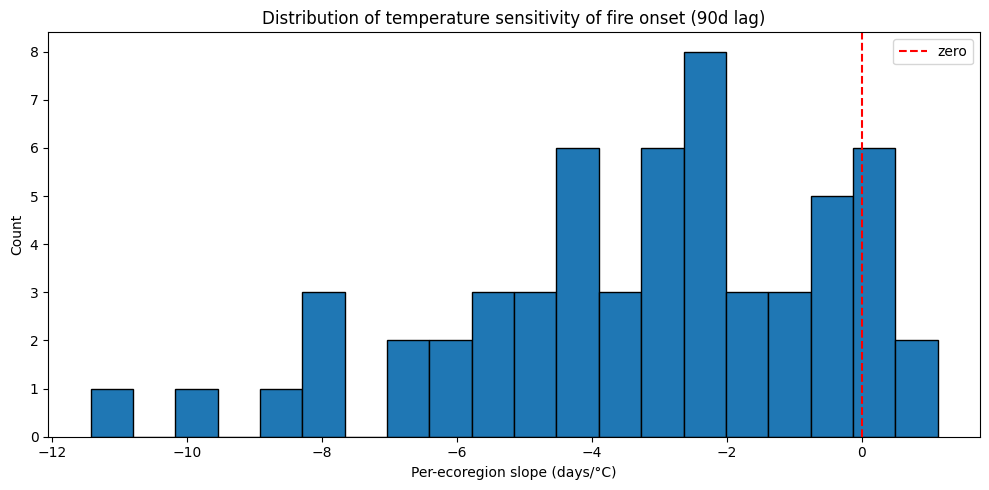

In [107]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(random_90d_temp['temp_anomaly_90d_slope_original'], bins=20, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero')
ax.set_xlabel('Per-ecoregion slope (days/°C)')
ax.set_ylabel('Count')
ax.set_title('Distribution of temperature sensitivity of fire onset (90d lag)')
ax.legend()
plt.tight_layout()
plt.show()

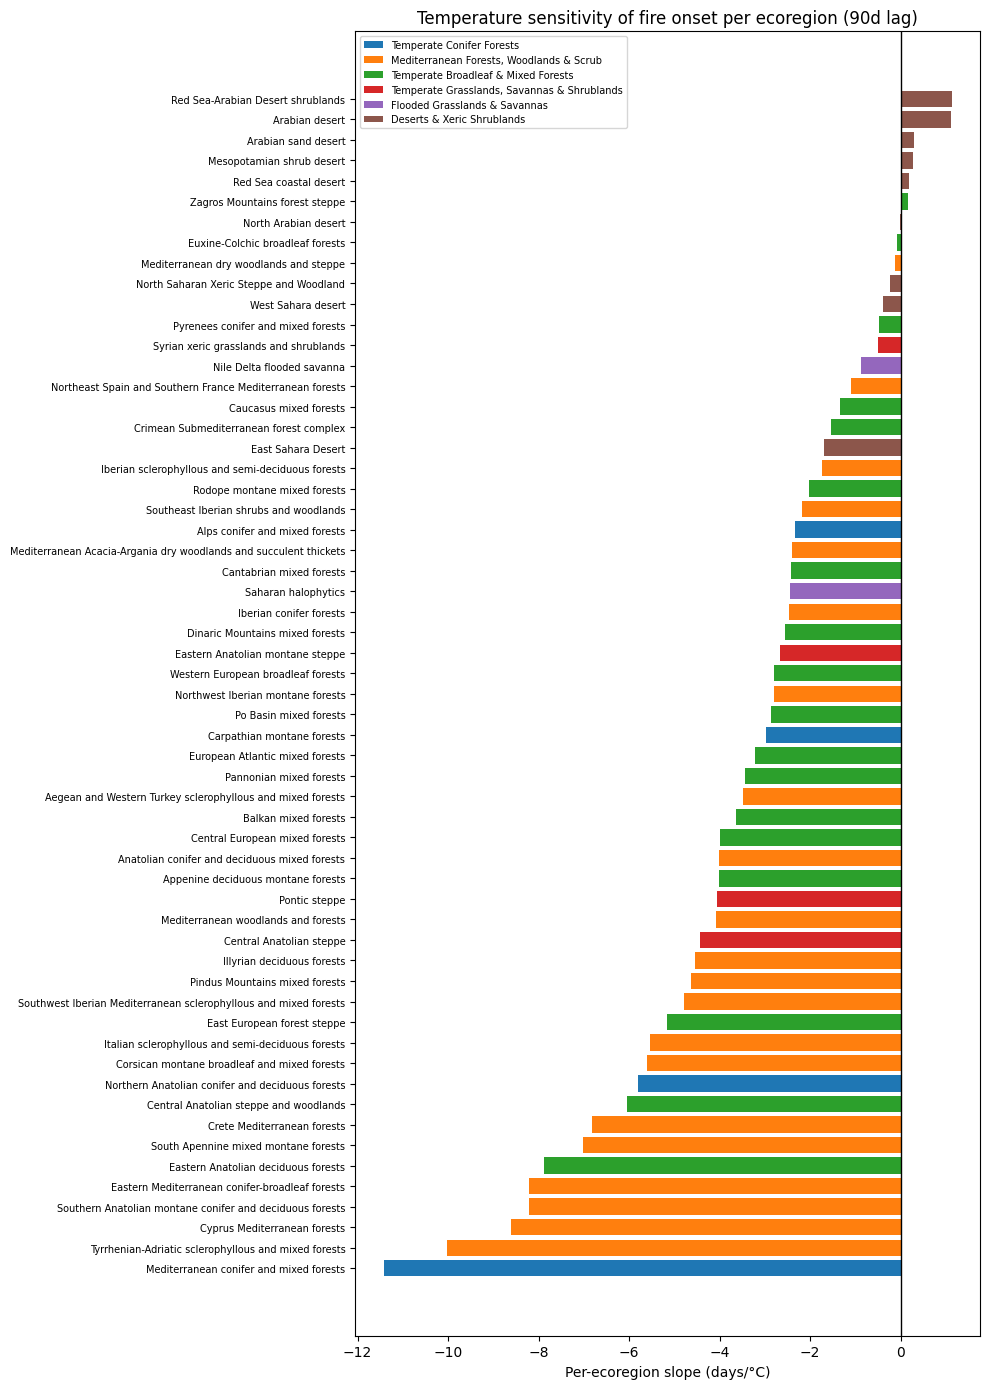

In [108]:
# Sort by slope value
eco_meta = df[['eco_id', 'eco_name', 'biome_name']].drop_duplicates()
forest_df = random_90d_temp[['eco_id', 'temp_anomaly_90d_slope_original']].merge(eco_meta, on='eco_id')
forest_df = forest_df.sort_values('temp_anomaly_90d_slope_original')

biomes = forest_df['biome_name'].unique()
palette = plt.cm.tab10.colors
biome_color_map = {biome: palette[i % len(palette)] for i, biome in enumerate(biomes)}
colors = [biome_color_map[b] for b in forest_df['biome_name']]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(range(len(forest_df)), forest_df['temp_anomaly_90d_slope_original'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(forest_df)))
ax.set_yticklabels(forest_df['eco_name'], fontsize=7)
ax.set_xlabel('Per-ecoregion slope (days/°C)')
ax.set_title('Temperature sensitivity of fire onset per ecoregion (90d lag)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=biome_color_map[b], label=b) for b in biomes]
ax.legend(handles=legend_elements, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

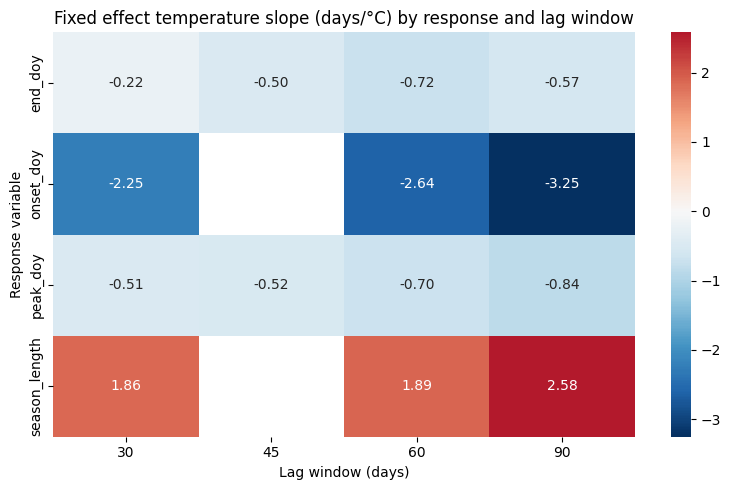

In [109]:
import seaborn as sns

heat_df = df_converged[df_converged['pred_set'] == 'temp'].copy()
heat_df['temp_coef'] = heat_df[['temp_anomaly_30d_coef_unscaled',
                                 'temp_anomaly_45d_coef_unscaled',
                                 'temp_anomaly_60d_coef_unscaled',
                                 'temp_anomaly_90d_coef_unscaled']].sum(axis=1, min_count=1)

pivot = heat_df.pivot(index='response', columns='lag', values='temp_coef')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Fixed effect temperature slope (days/°C) by response and lag window')
ax.set_xlabel('Lag window (days)')
ax.set_ylabel('Response variable')
plt.tight_layout()
plt.show()

In [114]:
import json

with open(r'C:\Users\ibekar\Documents\GitProjects\TGPF\runs\med_basin_v4\eco_geometries.json') as f:
    data = json.load(f)

# Check structure
print(type(data))
if isinstance(data, dict):
    print(data.keys())
elif isinstance(data, list):
    print(f'List of {len(data)} items')
    print(data[0].keys() if isinstance(data[0], dict) else data[0])

<class 'list'>
List of 59 items
dict_keys(['eco_id', 'eco_name', 'geometry'])


In [115]:
from shapely.geometry import shape

gdf = gpd.GeoDataFrame(
    [{'eco_id': d['eco_id'], 'eco_name': d['eco_name']} for d in data],
    geometry=[shape(d['geometry']) for d in data],
    crs='EPSG:4326'
)
print(gdf.head())
print(gdf.shape)

   eco_id                                 eco_name                                           geometry
0     701  Mediterranean conifer and mixed forests  MULTIPOLYGON (((5.80054 35.48919, 5.85768 35.4...
1     822                       East Sahara Desert  POLYGON ((8.09784 24.3184, 8.11729 24.24103, 8...
2     833  North Saharan Xeric Steppe and Woodland  MULTIPOLYGON (((34.51944 30.55778, 34.52248 30...
3     836                   Red Sea coastal desert  MULTIPOLYGON (((36.22701 23.56628, 36.24177 23...
4     845                       West Sahara desert  POLYGON ((-8.24031 26.24716, -8.24029 26.23201...
(59, 3)


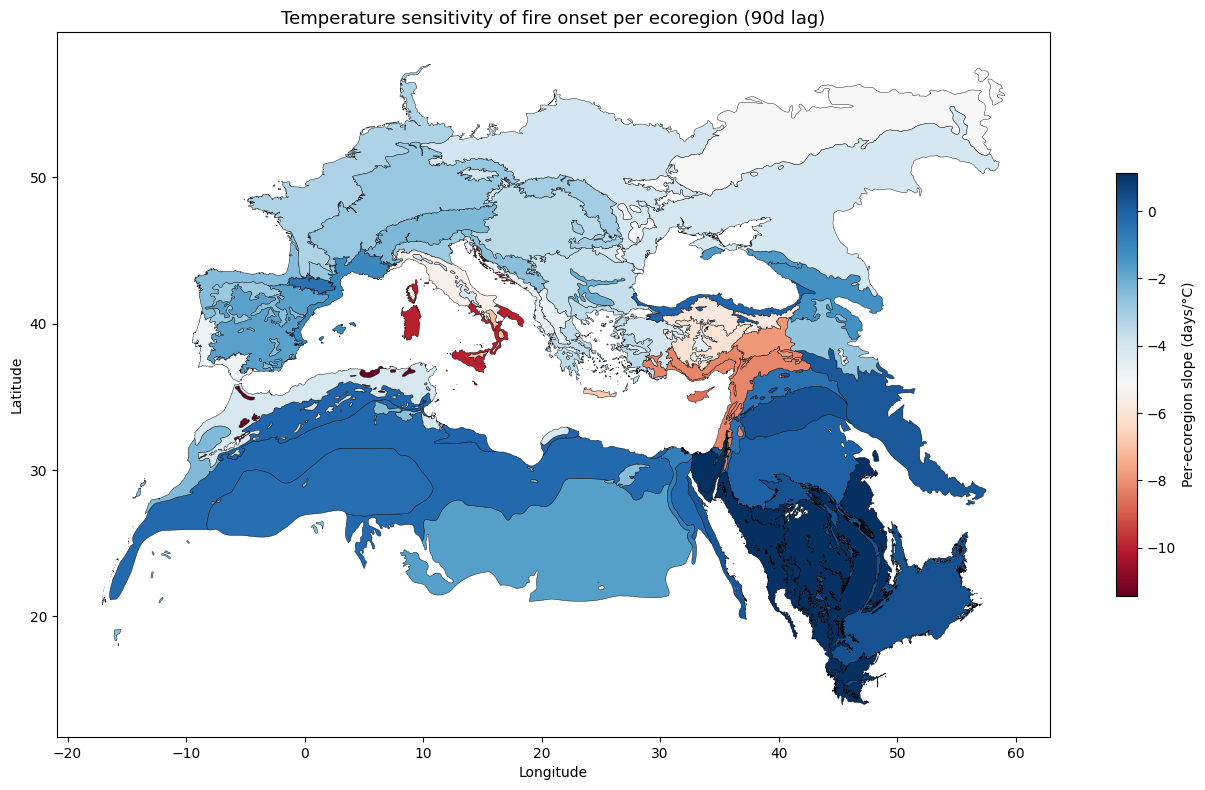

In [116]:
# Merge slopes into geodataframe
map_df = gdf.merge(forest_df[['eco_id', 'temp_anomaly_90d_slope_original', 'biome_name']], on='eco_id')

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
map_df.plot(
    column='temp_anomaly_90d_slope_original',
    cmap='RdBu',
    legend=True,
    legend_kwds={'label': 'Per-ecoregion slope (days/°C)', 'shrink': 0.6},
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)
ax.set_title('Temperature sensitivity of fire onset per ecoregion (90d lag)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()